# TUGAS PREPROCESSING
### RAVA DWI ANDIKA (25031554039)
### WELFEE PUTRI SUKARDI (25031554205) 

# IMPORT & DOWNLOAD LIBRARY

In [202]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from collections import Counter

print("Libraries imported successfully!")

Libraries imported successfully!


In [203]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("universal_tagset")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/macbookproi72019/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/macbookproi72019/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/macbookproi72019/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/macbookproi72019/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/macbookproi72019/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/macbookproi72019/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perc

True

# READ THE DATA

In [204]:
df = pd.read_csv("tmdb_top_rating.csv")

print("Dataset successfully loaded!")

display(df.head())

Dataset successfully loaded!


,ID,Title,Original Title,Release Date,Popularity,Vote Average,Vote Count,Original Language,Adult,Overview
0,969681,Spider-Man: Brand New Day,Spider-Man: Brand New Day,2026-07-29,690.8873,7.847,2730,en,False,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.
1,1204680,Coyote vs. Acme,Coyote vs. Acme,2026-08-20,539.5072,7.539,427,en,False,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation."
2,1375646,Colony,군체,2026-05-21,401.4199,8.083,805,ko,False,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations."
3,1368337,The Odyssey,The Odyssey,2026-07-15,383.2533,8.011,3750,en,False,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point."
4,1101383,The End of Oak Street,The End of Oak Street,2026-08-12,414.9533,6.879,968,en,False,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings."


# DATA OVERVIEW

In [205]:
print("Shape dataset:", df.shape)
print("\nColumns Name:")
print(df.columns.tolist())

df.info()
display(df.head())
df["Overview"]

Shape dataset: (100, 10)

Columns Name:
['ID', 'Title', 'Original Title', 'Release Date', 'Popularity', 'Vote Average', 'Vote Count', 'Original Language', 'Adult', 'Overview']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 100 non-null    int64  
 1   Title              100 non-null    object 
 2   Original Title     100 non-null    object 
 3   Release Date       100 non-null    object 
 4   Popularity         100 non-null    float64
 5   Vote Average       100 non-null    float64
 6   Vote Count         100 non-null    int64  
 7   Original Language  100 non-null    object 
 8   Adult              100 non-null    bool   
 9   Overview           98 non-null     object 
dtypes: bool(1), float64(2), int64(2), object(5)
memory usage: 7.3+ KB


,ID,Title,Original Title,Release Date,Popularity,Vote Average,Vote Count,Original Language,Adult,Overview
0,969681,Spider-Man: Brand New Day,Spider-Man: Brand New Day,2026-07-29,690.8873,7.847,2730,en,False,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.
1,1204680,Coyote vs. Acme,Coyote vs. Acme,2026-08-20,539.5072,7.539,427,en,False,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation."
2,1375646,Colony,군체,2026-05-21,401.4199,8.083,805,ko,False,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations."
3,1368337,The Odyssey,The Odyssey,2026-07-15,383.2533,8.011,3750,en,False,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point."
4,1101383,The End of Oak Street,The End of Oak Street,2026-08-12,414.9533,6.879,968,en,False,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings."


0                                                                    Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.
1                                                                                                                                                                                                                                                                               After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.
2                                                                                                                      P

# HANDLING MISSING VALUES

In [206]:
print("Missing value from Overview:")
print(df["Overview"].isna().sum())
print("Duplicate total:", df.duplicated().sum())

df = df.dropna(subset=["Overview"]).copy()
print("Data shape after removing missing values:", len(df))

Missing value from Overview:
2
Duplicate total: 6
Data shape after removing missing values: 98


# LOWER CASING

In [207]:
df["clean_overview"] = df["Overview"].astype(str)
df["clean_overview"] = df["clean_overview"].str.lower()
display(df[["Overview", "clean_overview"]].head())

,Overview,clean_overview
0,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.,fighting crime full-time as spider-man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in peter parker he may not have the power to control. but that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.
1,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.","after acme products fail him one too many times in his dogged pursuit of the roadrunner, wile e. coyote decides to hire a billboard lawyer to sue the acme corporation."
2,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations.","professor se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. trapped inside with no escape, se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations."
3,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point.","odysseus, the legendary king of ithaca, embarks on a long and perilous journey home following the trojan war. throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point."
4,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings.","after a mysterious cosmic event rips oak street from suburbia and transports their neighborhood to someplace unknown, the platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings."


# REMOVE HML TAGS

In [208]:
def remove_html(text):
    return BeautifulSoup(text,"html.parser").get_text(separator=" ")

df["clean_overview"] = df["clean_overview"].apply(remove_html)
pd.set_option("display.max_colwidth", None)
display(df[["Overview", "clean_overview"]].head())

,Overview,clean_overview
0,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.,fighting crime full-time as spider-man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in peter parker he may not have the power to control. but that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.
1,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.","after acme products fail him one too many times in his dogged pursuit of the roadrunner, wile e. coyote decides to hire a billboard lawyer to sue the acme corporation."
2,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations.","professor se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. trapped inside with no escape, se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations."
3,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point.","odysseus, the legendary king of ithaca, embarks on a long and perilous journey home following the trojan war. throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point."
4,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings.","after a mysterious cosmic event rips oak street from suburbia and transports their neighborhood to someplace unknown, the platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings."


# REMOVE URL

In [209]:
def remove_urls(text):
    return re.sub(r"http\S+|www\S+|https\S+","",text)

df["clean_overview"] = df["clean_overview"].apply(remove_urls)
pd.set_option("display.max_colwidth", None)
display(df[["Overview", "clean_overview"]].head())

,Overview,clean_overview
0,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.,fighting crime full-time as spider-man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in peter parker he may not have the power to control. but that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.
1,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.","after acme products fail him one too many times in his dogged pursuit of the roadrunner, wile e. coyote decides to hire a billboard lawyer to sue the acme corporation."
2,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations.","professor se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. trapped inside with no escape, se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations."
3,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point.","odysseus, the legendary king of ithaca, embarks on a long and perilous journey home following the trojan war. throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point."
4,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings.","after a mysterious cosmic event rips oak street from suburbia and transports their neighborhood to someplace unknown, the platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings."


# REMOVE PUNCTUATUION

In [210]:
def remove_punctuation(text):
    return text.translate(str.maketrans("","",string.punctuation))

df["clean_overview"] = df["clean_overview"].apply(remove_punctuation)
pd.set_option("display.max_colwidth", None)
display(df[["Overview", "clean_overview"]].head())

,Overview,clean_overview
0,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.,fighting crime fulltime as spiderman in a world that doesnt remember him—and the pressure of seeing his old friends move on without him—sparks a change in peter parker he may not have the power to control but that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves a powerful villain no one can even see
1,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.",after acme products fail him one too many times in his dogged pursuit of the roadrunner wile e coyote decides to hire a billboard lawyer to sue the acme corporation
2,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations.",professor sejeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility trapped inside with no escape sejeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations
3,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point.",odysseus the legendary king of ithaca embarks on a long and perilous journey home following the trojan war throughout his voyage he is forced to confront the whims of gods mythological monsters and trials that stretch both his cunning and his humanity to the breaking point
4,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings.",after a mysterious cosmic event rips oak street from suburbia and transports their neighborhood to someplace unknown the platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings


# REMOVE EMOJI

In [211]:
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FAFF"
    "\U00002700-\U000027BF"
    "\U00002600-\U000026FF"
    "]+",
    flags=re.UNICODE)

df["clean_overview"] = df["clean_overview"].str.replace(emoji_pattern,"",regex=True)
pd.set_option("display.max_colwidth", None)
display(df[["Overview", "clean_overview"]].head(7)[1:6])

,Overview,clean_overview
1,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.",after acme products fail him one too many times in his dogged pursuit of the roadrunner wile e coyote decides to hire a billboard lawyer to sue the acme corporation
2,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations.",professor sejeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility trapped inside with no escape sejeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations
3,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point.",odysseus the legendary king of ithaca embarks on a long and perilous journey home following the trojan war throughout his voyage he is forced to confront the whims of gods mythological monsters and trials that stretch both his cunning and his humanity to the breaking point
4,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings.",after a mysterious cosmic event rips oak street from suburbia and transports their neighborhood to someplace unknown the platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings
5,"A falsely accused war hero with nothing to lose leads police on an epic televised cross-country car chase, helped by members of his former Special Forces Army battalion and closely monitored by a fascinated public rooting for his safe getaway.",a falsely accused war hero with nothing to lose leads police on an epic televised crosscountry car chase helped by members of his former special forces army battalion and closely monitored by a fascinated public rooting for his safe getaway


# REMOVE EMOTICONS

In [212]:
emoticon_pattern = r"""
    [:;=8][\-^']?[)(DPp]
    |[:;=8][\-^']?[(/\\]
"""

df["clean_overview"] = df["clean_overview"].apply(lambda text: re.sub(emoticon_pattern,"",text,flags=re.VERBOSE))
pd.set_option("display.max_colwidth", None)
display(df[["Overview", "clean_overview"]].head())

,Overview,clean_overview
0,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.,fighting crime fulltime as spiderman in a world that doesnt remember him—and the pressure of seeing his old friends move on without him—sparks a change in peter parker he may not have the power to control but that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves a powerful villain no one can even see
1,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.",after acme products fail him one too many times in his dogged pursuit of the roadrunner wile e coyote decides to hire a billboard lawyer to sue the acme corporation
2,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations.",professor sejeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility trapped inside with no escape sejeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations
3,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point.",odysseus the legendary king of ithaca embarks on a long and perilous journey home following the trojan war throughout his voyage he is forced to confront the whims of gods mythological monsters and trials that stretch both his cunning and his humanity to the breaking point
4,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings.",after a mysterious cosmic event rips oak street from suburbia and transports their neighborhood to someplace unknown the platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings


# REMOVE STOPWORDS

In [213]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["clean_overview"] = df["clean_overview"].apply(
    lambda text: " ".join(
        word
        for word in text.split()
        if word not in stop_words
    )
)


pd.set_option("display.max_colwidth", None)
display(df[["Overview", "clean_overview"]].head())

,Overview,clean_overview
0,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.,fighting crime fulltime spiderman world doesnt remember him—and pressure seeing old friends move without him—sparks change peter parker may power control transformation might also thing stop shocking new threat city loves powerful villain one even see
1,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.",acme products fail one many times dogged pursuit roadrunner wile e coyote decides hire billboard lawyer sue acme corporation
2,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations.",professor sejeong thrust bloody nightmare rapidly mutating virus released biotech conference causing authorities seal facility trapped inside escape sejeong along small group survivors must fight stay alive infected undergo horrific transformations
3,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point.",odysseus legendary king ithaca embarks long perilous journey home following trojan war throughout voyage forced confront whims gods mythological monsters trials stretch cunning humanity breaking point
4,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings.",mysterious cosmic event rips oak street suburbia transports neighborhood someplace unknown platt family soon discovers survival depends sticking together navigate unrecognizable surroundings


# ANALYZE FREQUENT WORDS

In [214]:
all_words = " ".join(
    df["clean_overview"]
).split()

word_freq = Counter(all_words)

freq_df = pd.DataFrame(
    word_freq.most_common(20),
    columns=["word", "frequency"]
)

display(freq_df)

,word,frequency
0,life,22
1,world,20
2,one,18
3,new,17
4,must,17
5,family,17
6,mysterious,10
7,help,10
8,threat,9
9,group,9


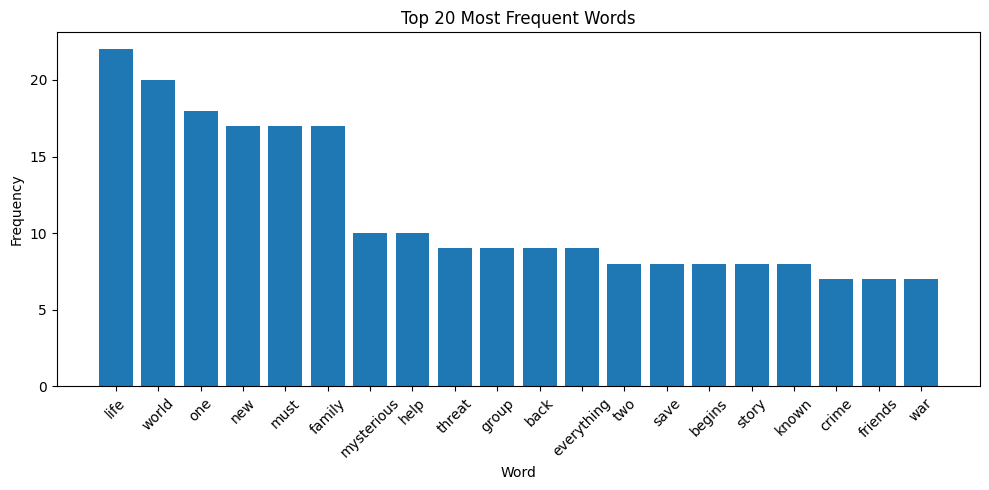

In [215]:
plt.figure(figsize=(10, 5))

plt.bar(
    freq_df["word"],
    freq_df["frequency"]
)

plt.xticks(rotation=45)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words")

plt.tight_layout()
plt.show()

# REMOVE FREQUENT WORDS

In [216]:
frequent_words = set(
    word
    for word, count in word_freq.most_common(10)
)

print("Deleted frequent words:")
print(frequent_words)

df["clean_overview"] = df["clean_overview"].apply(
    lambda text: " ".join(
        word
        for word in text.split()
        if word not in frequent_words
    )
)
pd.set_option("display.max_colwidth", None)
display(df[["Overview", "clean_overview"]].head())

Deleted frequent words:
{'must', 'one', 'mysterious', 'family', 'world', 'help', 'new', 'threat', 'life', 'group'}


,Overview,clean_overview
0,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.,fighting crime fulltime spiderman doesnt remember him—and pressure seeing old friends move without him—sparks change peter parker may power control transformation might also thing stop shocking city loves powerful villain even see
1,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.",acme products fail many times dogged pursuit roadrunner wile e coyote decides hire billboard lawyer sue acme corporation
2,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations.",professor sejeong thrust bloody nightmare rapidly mutating virus released biotech conference causing authorities seal facility trapped inside escape sejeong along small survivors fight stay alive infected undergo horrific transformations
3,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point.",odysseus legendary king ithaca embarks long perilous journey home following trojan war throughout voyage forced confront whims gods mythological monsters trials stretch cunning humanity breaking point
4,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings.",cosmic event rips oak street suburbia transports neighborhood someplace unknown platt soon discovers survival depends sticking together navigate unrecognizable surroundings


# REMOVE RARE WORDS

In [217]:
all_words_after_freq = " ".join(
    df["clean_overview"]
).split()

word_freq_after_freq = Counter(
    all_words_after_freq
)

rare_words = {
    word
    for word, count in word_freq_after_freq.items()
    if count == 1
}

print("Rare words total:", len(rare_words))

df["clean_overview"] = df["clean_overview"].apply(
    lambda text: " ".join(
        word
        for word in text.split()
        if word not in rare_words
    )
)
pd.set_option("display.max_colwidth", None)
display(df[["Overview", "clean_overview"]].head(6))

Rare words total: 1078


,Overview,clean_overview
0,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.,fighting crime fulltime spiderman seeing old friends move without peter parker power control might stop city loves powerful villain even see
1,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.",acme pursuit decides lawyer acme corporation
2,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations.",sejeong bloody nightmare released causing trapped escape sejeong along small fight
3,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point.",legendary king embarks long journey home following war throughout voyage forced confront monsters stretch humanity breaking point
4,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings.",cosmic event neighborhood unknown soon discovers survival together
5,"A falsely accused war hero with nothing to lose leads police on an epic televised cross-country car chase, helped by members of his former Special Forces Army battalion and closely monitored by a fascinated public rooting for his safe getaway.",war hero nothing leads police epic chase members former special forces safe


# CHAT WORDS CONVERSION

In [218]:
chat_words = {
    "u": "you",
    "ur": "your",
    "r": "are",
    "btw": "by the way",
    "idk": "i do not know",
    "omg": "oh my god",
    "thx": "thanks",
    "pls": "please"
}

df["clean_overview"] = df["clean_overview"].apply(
    lambda text: " ".join(
        chat_words.get(word, word)
        for word in text.split()
    )
)

display(df[["Overview", "clean_overview"]].head())

,Overview,clean_overview
0,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.,fighting crime fulltime spiderman seeing old friends move without peter parker power control might stop city loves powerful villain even see
1,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.",acme pursuit decides lawyer acme corporation
2,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations.",sejeong bloody nightmare released causing trapped escape sejeong along small fight
3,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point.",legendary king embarks long journey home following war throughout voyage forced confront monsters stretch humanity breaking point
4,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings.",cosmic event neighborhood unknown soon discovers survival together


# SPELLING CORRECTION

In [219]:
print(
    "Spelling correction is not automatically applied."
)

print(
    "Reason: TMDB overviews contain proper nouns "
    "such as character names, locations, and fictional terms."
)

Spelling correction is not automatically applied.
Reason: TMDB overviews contain proper nouns such as character names, locations, and fictional terms.


# TEXT NORMALIZATION

In [220]:
df["clean_overview"] = df["clean_overview"].apply(
    lambda text: re.sub(r"\s+", " ", text).strip()
)

display(df[["Overview", "clean_overview"]].head())

,Overview,clean_overview
0,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.,fighting crime fulltime spiderman seeing old friends move without peter parker power control might stop city loves powerful villain even see
1,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.",acme pursuit decides lawyer acme corporation
2,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations.",sejeong bloody nightmare released causing trapped escape sejeong along small fight
3,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point.",legendary king embarks long journey home following war throughout voyage forced confront monsters stretch humanity breaking point
4,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings.",cosmic event neighborhood unknown soon discovers survival together


# BASIC PREPROCESSING RESULT

In [221]:
pd.set_option("display.max_colwidth", None)

display(
    df[
        [
            "Overview",
            "clean_overview"
        ]
    ].head(5)
)

print("ORIGINAL:")
print(df["Overview"].iloc[0])
print("\nCLEAN:")
print(df["clean_overview"].iloc[0])

,Overview,clean_overview
0,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.,fighting crime fulltime spiderman seeing old friends move without peter parker power control might stop city loves powerful villain even see
1,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.",acme pursuit decides lawyer acme corporation
2,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations.",sejeong bloody nightmare released causing trapped escape sejeong along small fight
3,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point.",legendary king embarks long journey home following war throughout voyage forced confront monsters stretch humanity breaking point
4,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings.",cosmic event neighborhood unknown soon discovers survival together


ORIGINAL:
Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.

CLEAN:
fighting crime fulltime spiderman seeing old friends move without peter parker power control might stop city loves powerful villain even see


# WORD COUNT COMPARISON

In [222]:
df["original_word_count"] = (
    df["Overview"]
    .astype(str)
    .str.split()
    .str.len()
)

df["clean_word_count"] = (
    df["clean_overview"]
    .str.split()
    .str.len()
)

print(
    "Average original word count:",
    df["original_word_count"].mean()
)

print(
    "Average clean word count:",
    df["clean_word_count"].mean()
)

Average original word count: 45.775510204081634
Average clean word count: 14.0


# STEMMING

In [223]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df["stemmed_overview"] = df["clean_overview"].apply(
    lambda text: " ".join(
        stemmer.stem(word)
        for word in text.split()
    )
)

display(
    df[
        [
            "clean_overview",
            "stemmed_overview"
        ]
    ].head(10)
)

,clean_overview,stemmed_overview
0,fighting crime fulltime spiderman seeing old friends move without peter parker power control might stop city loves powerful villain even see,fight crime fulltim spiderman see old friend move without peter parker power control might stop citi love power villain even see
1,acme pursuit decides lawyer acme corporation,acm pursuit decid lawyer acm corpor
2,sejeong bloody nightmare released causing trapped escape sejeong along small fight,sejeong bloodi nightmar releas caus trap escap sejeong along small fight
3,legendary king embarks long journey home following war throughout voyage forced confront monsters stretch humanity breaking point,legendari king embark long journey home follow war throughout voyag forc confront monster stretch human break point
4,cosmic event neighborhood unknown soon discovers survival together,cosmic event neighborhood unknown soon discov surviv togeth
5,war hero nothing leads police epic chase members former special forces safe,war hero noth lead polic epic chase member former special forc safe
6,boss murder crime cargo crusade boss death discover international,boss murder crime cargo crusad boss death discov intern
7,call first time beyond island unforgettable journey restore people,call first time beyond island unforgett journey restor peopl
8,daughter powerful spanish york upside released without father forced every together nothing seems,daughter power spanish york upsid releas without father forc everi togeth noth seem
9,romance man woman unexpected event end two try overcome,romanc man woman unexpect event end two tri overcom


# LEMMATIZATION

In [224]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df["lemmatized_overview"] = df["clean_overview"].apply(
    lambda text: " ".join(
        lemmatizer.lemmatize(word)
        for word in text.split()
    )
)

display(
    df[
        [
            "clean_overview",
            "lemmatized_overview"
        ]
    ].head(10)
)

,clean_overview,lemmatized_overview
0,fighting crime fulltime spiderman seeing old friends move without peter parker power control might stop city loves powerful villain even see,fighting crime fulltime spiderman seeing old friend move without peter parker power control might stop city love powerful villain even see
1,acme pursuit decides lawyer acme corporation,acme pursuit decides lawyer acme corporation
2,sejeong bloody nightmare released causing trapped escape sejeong along small fight,sejeong bloody nightmare released causing trapped escape sejeong along small fight
3,legendary king embarks long journey home following war throughout voyage forced confront monsters stretch humanity breaking point,legendary king embarks long journey home following war throughout voyage forced confront monster stretch humanity breaking point
4,cosmic event neighborhood unknown soon discovers survival together,cosmic event neighborhood unknown soon discovers survival together
5,war hero nothing leads police epic chase members former special forces safe,war hero nothing lead police epic chase member former special force safe
6,boss murder crime cargo crusade boss death discover international,bos murder crime cargo crusade bos death discover international
7,call first time beyond island unforgettable journey restore people,call first time beyond island unforgettable journey restore people
8,daughter powerful spanish york upside released without father forced every together nothing seems,daughter powerful spanish york upside released without father forced every together nothing seems
9,romance man woman unexpected event end two try overcome,romance man woman unexpected event end two try overcome


# COMPARISON

In [225]:
display(
    df[
        [
            "Overview",
            "clean_overview",
            "stemmed_overview",
            "lemmatized_overview"
        ]
    ].head(5)
)

for i in range(3):
    print("=" * 80)
    print("ORIGINAL:")
    print(df["Overview"].iloc[i])

    print("\nCLEAN:")
    print(df["clean_overview"].iloc[i])

    print("\nSTEMMED:")
    print(df["stemmed_overview"].iloc[i])

    print("\nLEMMATIZED:")
    print(df["lemmatized_overview"].iloc[i])

,Overview,clean_overview,stemmed_overview,lemmatized_overview
0,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.,fighting crime fulltime spiderman seeing old friends move without peter parker power control might stop city loves powerful villain even see,fight crime fulltim spiderman see old friend move without peter parker power control might stop citi love power villain even see,fighting crime fulltime spiderman seeing old friend move without peter parker power control might stop city love powerful villain even see
1,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.",acme pursuit decides lawyer acme corporation,acm pursuit decid lawyer acm corpor,acme pursuit decides lawyer acme corporation
2,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations.",sejeong bloody nightmare released causing trapped escape sejeong along small fight,sejeong bloodi nightmar releas caus trap escap sejeong along small fight,sejeong bloody nightmare released causing trapped escape sejeong along small fight
3,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point.",legendary king embarks long journey home following war throughout voyage forced confront monsters stretch humanity breaking point,legendari king embark long journey home follow war throughout voyag forc confront monster stretch human break point,legendary king embarks long journey home following war throughout voyage forced confront monster stretch humanity breaking point
4,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival depends on them sticking together as they navigate their now unrecognizable surroundings.",cosmic event neighborhood unknown soon discovers survival together,cosmic event neighborhood unknown soon discov surviv togeth,cosmic event neighborhood unknown soon discovers survival together


ORIGINAL:
Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.

CLEAN:
fighting crime fulltime spiderman seeing old friends move without peter parker power control might stop city loves powerful villain even see

STEMMED:
fight crime fulltim spiderman see old friend move without peter parker power control might stop citi love power villain even see

LEMMATIZED:
fighting crime fulltime spiderman seeing old friend move without peter parker power control might stop city love powerful villain even see
ORIGINAL:
After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.



# POST TAGGING

In [226]:
def pos_tag_text(text):
    tokens = nltk.word_tokenize(text)

    return nltk.pos_tag(
        tokens,
        tagset="universal"
    )

df["pos_tags"] = df["clean_overview"].apply(
    pos_tag_text
)

display(
    df[
        [
            "clean_overview",
            "pos_tags"
        ]
    ].head(5)
)

sentence = df["clean_overview"].iloc[0]

tokens = nltk.word_tokenize(sentence)

pos_tags = nltk.pos_tag(
    tokens,
    tagset="universal"
)

for word, tag in pos_tags:
    print(f"{word:<20} {tag}")

,clean_overview,pos_tags
0,fighting crime fulltime spiderman seeing old friends move without peter parker power control might stop city loves powerful villain even see,"[(fighting, VERB), (crime, NOUN), (fulltime, NOUN), (spiderman, NOUN), (seeing, VERB), (old, ADJ), (friends, NOUN), (move, VERB), (without, ADP), (peter, NOUN), (parker, NOUN), (power, NOUN), (control, NOUN), (might, VERB), (stop, VERB), (city, NOUN), (loves, NOUN), (powerful, ADJ), (villain, ADV), (even, ADV), (see, VERB)]"
1,acme pursuit decides lawyer acme corporation,"[(acme, ADJ), (pursuit, NOUN), (decides, VERB), (lawyer, NOUN), (acme, NOUN), (corporation, NOUN)]"
2,sejeong bloody nightmare released causing trapped escape sejeong along small fight,"[(sejeong, ADJ), (bloody, NOUN), (nightmare, NOUN), (released, VERB), (causing, VERB), (trapped, VERB), (escape, NOUN), (sejeong, NOUN), (along, ADP), (small, ADJ), (fight, NOUN)]"
3,legendary king embarks long journey home following war throughout voyage forced confront monsters stretch humanity breaking point,"[(legendary, ADJ), (king, NOUN), (embarks, NOUN), (long, ADJ), (journey, NOUN), (home, NOUN), (following, VERB), (war, NOUN), (throughout, ADP), (voyage, NOUN), (forced, VERB), (confront, ADJ), (monsters, NOUN), (stretch, VERB), (humanity, NOUN), (breaking, NOUN), (point, NOUN)]"
4,cosmic event neighborhood unknown soon discovers survival together,"[(cosmic, ADJ), (event, NOUN), (neighborhood, NOUN), (unknown, ADJ), (soon, ADV), (discovers, NOUN), (survival, VERB), (together, ADV)]"


fighting             VERB
crime                NOUN
fulltime             NOUN
spiderman            NOUN
seeing               VERB
old                  ADJ
friends              NOUN
move                 VERB
without              ADP
peter                NOUN
parker               NOUN
power                NOUN
control              NOUN
might                VERB
stop                 VERB
city                 NOUN
loves                NOUN
powerful             ADJ
villain              ADV
even                 ADV
see                  VERB


# CHUNKING

In [227]:
grammar = r"""
    NP: {<DET>?<ADJ>*<NOUN>+}
    VP: {<VERB><.*>*}
    PP: {<ADP><NP>}
    ADJP: {<ADV>*<ADJ>+}
"""

chunk_parser = nltk.RegexpParser(grammar)

sentence = df["clean_overview"].iloc[0]

tokens = nltk.word_tokenize(sentence)

tagged_sentence = nltk.pos_tag(
    tokens,
    tagset="universal"
)

chunk_tree = chunk_parser.parse(
    tagged_sentence
)

print(chunk_tree)
chunk_tree.pretty_print()

(S
  (VP
    fighting/VERB
    (NP crime/NOUN fulltime/NOUN spiderman/NOUN)
    seeing/VERB
    (NP old/ADJ friends/NOUN)
    move/VERB
    without/ADP
    (NP peter/NOUN parker/NOUN power/NOUN control/NOUN)
    might/VERB
    stop/VERB
    (NP city/NOUN loves/NOUN)
    powerful/ADJ
    villain/ADV
    even/ADV
    see/VERB))
                                                                                                                    S                                                                                                                                   
                                                                                                                    |                                                                                                                                    
                                                                                                                    VP                                                       

# FINAL DATASET

In [228]:
print("Shape:", df.shape)

print("\nColumns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

display(df.head())

output_file = "tmdb_preprocessed.csv"

df.to_csv(
    output_file,
    index=False
)

print(f"Dataset already saved as: {output_file}")

Shape: (98, 16)

Columns:
1. ID
2. Title
3. Original Title
4. Release Date
5. Popularity
6. Vote Average
7. Vote Count
8. Original Language
9. Adult
10. Overview
11. clean_overview
12. original_word_count
13. clean_word_count
14. stemmed_overview
15. lemmatized_overview
16. pos_tags


,ID,Title,Original Title,Release Date,Popularity,Vote Average,Vote Count,Original Language,Adult,Overview,clean_overview,original_word_count,clean_word_count,stemmed_overview,lemmatized_overview,pos_tags
0,969681,Spider-Man: Brand New Day,Spider-Man: Brand New Day,2026-07-29,690.8873,7.847,2730,en,False,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.,fighting crime fulltime spiderman seeing old friends move without peter parker power control might stop city loves powerful villain even see,68,21,fight crime fulltim spiderman see old friend move without peter parker power control might stop citi love power villain even see,fighting crime fulltime spiderman seeing old friend move without peter parker power control might stop city love powerful villain even see,"[(fighting, VERB), (crime, NOUN), (fulltime, NOUN), (spiderman, NOUN), (seeing, VERB), (old, ADJ), (friends, NOUN), (move, VERB), (without, ADP), (peter, NOUN), (parker, NOUN), (power, NOUN), (control, NOUN), (might, VERB), (stop, VERB), (city, NOUN), (loves, NOUN), (powerful, ADJ), (villain, ADV), (even, ADV), (see, VERB)]"
1,1204680,Coyote vs. Acme,Coyote vs. Acme,2026-08-20,539.5072,7.539,427,en,False,"After Acme products fail him one too many times in his dogged pursuit of the Roadrunner, Wile E. Coyote decides to hire a billboard lawyer to sue the Acme Corporation.",acme pursuit decides lawyer acme corporation,30,6,acm pursuit decid lawyer acm corpor,acme pursuit decides lawyer acme corporation,"[(acme, ADJ), (pursuit, NOUN), (decides, VERB), (lawyer, NOUN), (acme, NOUN), (corporation, NOUN)]"
2,1375646,Colony,군체,2026-05-21,401.4199,8.083,805,ko,False,"Professor Se-jeong is thrust into a bloody nightmare when a rapidly mutating virus is released during a biotech conference causing authorities to seal the facility. Trapped inside with no escape, Se-jeong along with a small group of survivors must fight to stay alive while the infected undergo horrific transformations.",sejeong bloody nightmare released causing trapped escape sejeong along small fight,49,11,sejeong bloodi nightmar releas caus trap escap sejeong along small fight,sejeong bloody nightmare released causing trapped escape sejeong along small fight,"[(sejeong, ADJ), (bloody, NOUN), (nightmare, NOUN), (released, VERB), (causing, VERB), (trapped, VERB), (escape, NOUN), (sejeong, NOUN), (along, ADP), (small, ADJ), (fight, NOUN)]"
3,1368337,The Odyssey,The Odyssey,2026-07-15,383.2533,8.011,3750,en,False,"Odysseus, the legendary King of Ithaca, embarks on a long and perilous journey home following the Trojan War. Throughout his voyage, he is forced to confront the whims of gods, mythological monsters, and trials that stretch both his cunning and his humanity to the breaking point.",legendary king embarks long journey home following war throughout voyage forced confront monsters stretch humanity breaking point,46,17,legendari king embark long journey home follow war throughout voyag forc confront monster stretch human break point,legendary king embarks long journey home following war throughout voyage forced confront monster stretch humanity breaking point,"[(legendary, ADJ), (king, NOUN), (embarks, NOUN), (long, ADJ), (journey, NOUN), (home, NOUN), (following, VERB), (war, NOUN), (throughout, ADP), (voyage, NOUN), (forced, VERB), (confront, ADJ), (monsters, NOUN), (stretch, VERB), (humanity, NOUN), (breaking, NOUN), (point, NOUN)]"
4,1101383,The End of Oak Street,The End of Oak Street,2026-08-12,414.9533,6.879,968,en,False,"After a mysterious cosmic event rips Oak Street from suburbia and transports their neighborhood to someplace unknown, the Platt family soon discovers that their very survival 

Dataset already saved as: tmdb_preprocessed.csv
